In [ ]:
from sklearn.datasets import load_wine
wine = load_wine()
wine

In [ ]:
wine.data.shape, wine.data.ndim

In [ ]:
wine.feature_names

In [ ]:
import pandas as pd
wine_df = pd.DataFrame(wine.data,columns=wine.feature_names)
wine_df.head()

In [ ]:
# 컬럼중에서 x y 가 될만한 컬럼을 찾아보기.... 선형성이 있는지 시각적으로 또는 상관계수를 통해서 학습할수 있는 데이터찾기

In [ ]:
import seaborn as sns
wine.feature_names
# total_phenols 'flavanoids'
sns.scatterplot(data=wine_df,x='total_phenols' ,y='flavanoids')

In [ ]:
import seaborn as sns
sns.pairplot(data= wine_df)

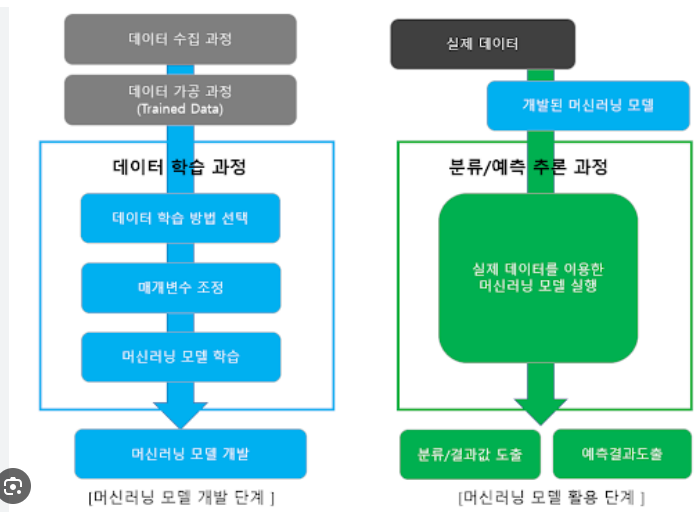

선형관계가 있는 데이터 셋을 찾는다(2개 x y)

학습용 테스트용 데이터 분리

모델 선택

학습

평가

In [ ]:
from sklearn.model_selection import train_test_split
# flavanoids', y='proline
X = wine_df[['flavanoids']]
y = wine_df.proline
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)
len(x_train), len(y_train), len(x_test), len(y_test)

In [ ]:
# 모델 선택 및 학습
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

In [ ]:
# 평가  결정계수
lr.score(x_test, y_test)

In [ ]:
# 비선형으로 try
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=7)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
lr2 = LinearRegression()
lr2.fit(x_train_poly,y_train)

In [ ]:
lr2.score(x_test_poly,y_test)

In [ ]:
# wine_df  flavanoids  proanthocyanins
import matplotlib.pylab as plt
y_test_predict = lr.predict(x_test)
y_test_poly_predict = lr2.predict(x_test_poly)
sns.scatterplot(data=wine_df,x='flavanoids', y='proline')
# len(x_test), len(y_test_predict)
plt.scatter(x = x_test, y = y_test_predict)
plt.scatter(x = x_test, y = y_test_poly_predict)